In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import os
import pandas as pd

PROJECT_DIR = "/content/drive/MyDrive/Multimedia_Authentication"
SPLIT_FILE = f"{PROJECT_DIR}/splits/ffpp_6000_split.csv"

df = pd.read_csv(SPLIT_FILE)

print("Dataset split loaded!")
print(df["split"].value_counts())

Dataset split loaded!
split
train    4200
val       900
test      900
Name: count, dtype: int64


In [7]:
import os
import kagglehub

DATASET_DIR = "/root/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1"
RAW_DATASET = os.path.join(
    DATASET_DIR,
    "FaceForensics++_C23"
)

if os.path.exists(RAW_DATASET):
    print("Raw dataset already available.")
else:
    print("Raw dataset not found. Downloading from Kaggle...")

    downloaded_path = kagglehub.dataset_download(
        "xdxd003/ff-c23"
    )

    print("Downloaded to:", downloaded_path)

    RAW_DATASET = os.path.join(
        downloaded_path,
        "FaceForensics++_C23"
    )

print("Raw dataset:", RAW_DATASET)
print("Exists:", os.path.exists(RAW_DATASET))

Raw dataset not found. Downloading from Kaggle...


100%|██████████| 16.7G/16.7G [01:56<00:00, 153MB/s]

Extracting files...


Downloaded to: /root/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1
Raw dataset: /root/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23
Exists: True


In [8]:
import pandas as pd

df = pd.read_csv(SPLIT_FILE)

print("Total videos:", len(df))
print("\nSplits:")
print(df["split"].value_counts())

print("\nLabels:")
print(df["Label"].value_counts())

Total videos: 6000

Splits:
split
train    4200
val       900
test      900
Name: count, dtype: int64

Labels:
Label
FAKE    5000
REAL    1000
Name: count, dtype: int64


In [9]:
import cv2
import os

def extract_frames(path, num_frames=8):
    cap = cv2.VideoCapture(path)

    if not cap.isOpened():
        print("Could not open:", path)
        return []

    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    print("Frames:", frame_count)
    print("FPS:", fps)
    print("Resolution:", width, "x", height)

    indices = [
        int(i * (frame_count - 1) / (num_frames - 1))
        for i in range(num_frames)
    ]

    frames = []

    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        success, frame = cap.read()

        if success:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)

    cap.release()

    print("Successfully extracted:", len(frames))

    return frames

In [10]:
import cv2
import os

original_dir = os.path.join(RAW_DATASET, "original")
deepfake_dir = os.path.join(RAW_DATASET, "Deepfakes")

# Find a valid matching pair
original_files = set(os.listdir(original_dir))

for fake_file in os.listdir(deepfake_dir):
    if "_" in fake_file:
        source_id = fake_file.split("_")[0] + ".mp4"

        if source_id in original_files:
            print("REAL:", source_id)
            print("FAKE:", fake_file)
            break

REAL: 873.mp4
FAKE: 873_872.mp4


In [11]:
real_path = os.path.join(original_dir, source_id)
fake_path = os.path.join(deepfake_dir, fake_file)

real_frames = extract_frames(real_path, 8)
fake_frames = extract_frames(fake_path, 8)

Frames: 884
FPS: 25.0
Resolution: 1280 x 720
Successfully extracted: 8
Frames: 884
FPS: 25.0
Resolution: 1280 x 720
Successfully extracted: 8


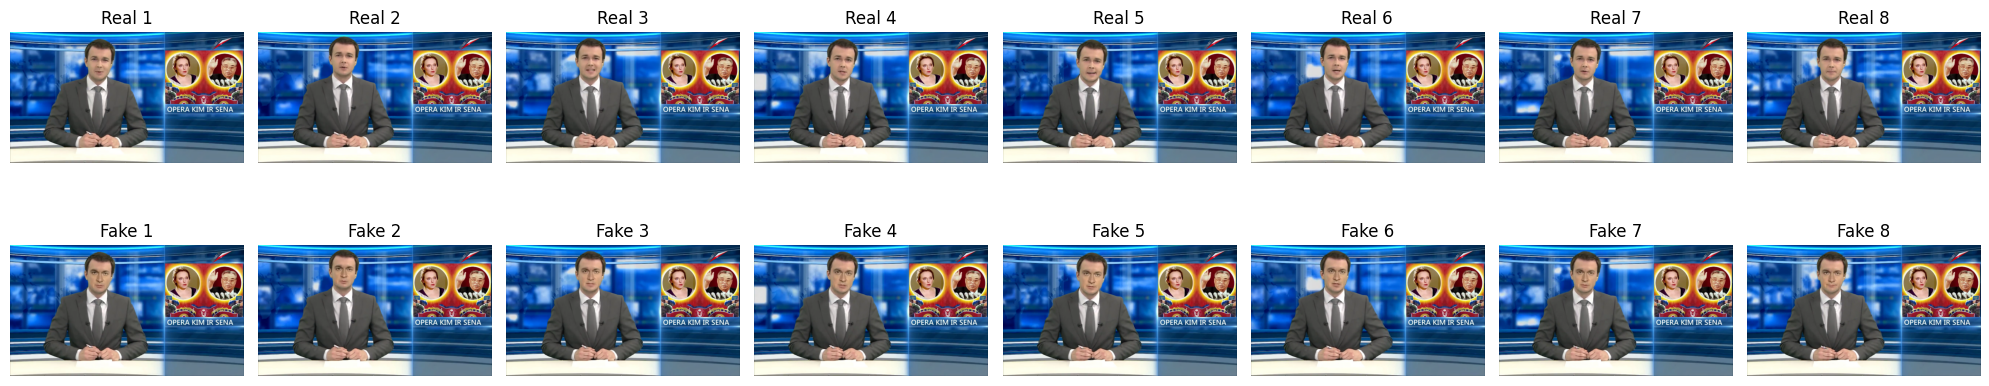

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 8, figsize=(20, 5))

for i, frame in enumerate(real_frames):
    axes[0, i].imshow(frame)
    axes[0, i].axis("off")
    axes[0, i].set_title(f"Real {i+1}")

for i, frame in enumerate(fake_frames):
    axes[1, i].imshow(frame)
    axes[1, i].axis("off")
    axes[1, i].set_title(f"Fake {i+1}")

plt.tight_layout()
plt.show()

In [13]:
import os
import pandas as pd
import numpy as np
import cv2
from tqdm.auto import tqdm

PROJECT_DIR = "/content/drive/MyDrive/Multimedia_Authentication"

FRAMES_DIR = os.path.join(PROJECT_DIR, "frames")
os.makedirs(FRAMES_DIR, exist_ok=True)

print("Frames will be stored at:", FRAMES_DIR)

Frames will be stored at: /content/drive/MyDrive/Multimedia_Authentication/frames


In [14]:
SPLIT_FILE = os.path.join(
    PROJECT_DIR,
    "splits",
    "ffpp_6000_split.csv"
)

df = pd.read_csv(SPLIT_FILE)

print("Total videos:", len(df))
print(df["split"].value_counts())
print(df["Label"].value_counts())

Total videos: 6000
split
train    4200
val       900
test      900
Name: count, dtype: int64
Label
FAKE    5000
REAL    1000
Name: count, dtype: int64


In [15]:
def extract_frames(path, num_frames=8, image_size=(224, 224)):
    cap = cv2.VideoCapture(path)

    if not cap.isOpened():
        return None

    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if frame_count <= 0:
        cap.release()
        return None

    indices = np.linspace(
        0,
        frame_count - 1,
        num_frames,
        dtype=int
    )

    frames = []

    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))

        success, frame = cap.read()

        if not success:
            cap.release()
            return None

        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = cv2.resize(frame, image_size)

        frames.append(frame)

    cap.release()

    return np.array(frames, dtype=np.uint8)

In [16]:
test_row = df.iloc[0]

video_path = os.path.join(
    RAW_DATASET,
    test_row["File Path"]
)

frames = extract_frames(video_path)

print("Video:", test_row["File Path"])
print("Frames shape:", frames.shape)

Video: original/500.mp4
Frames shape: (8, 224, 224, 3)


In [17]:
test_output = os.path.join(FRAMES_DIR, "test_sample.npz")

np.savez_compressed(
    test_output,
    frames=frames
)

print("Saved:", test_output)
print("File size:", os.path.getsize(test_output) / (1024**2), "MB")

Saved: /content/drive/MyDrive/Multimedia_Authentication/frames/test_sample.npz
File size: 0.7264518737792969 MB


In [18]:
loaded = np.load(test_output)

print(loaded["frames"].shape)

(8, 224, 224, 3)


In [19]:
import os

os.remove("/content/drive/MyDrive/Multimedia_Authentication/frames/test_sample.npz")

print("Test file removed.")

Test file removed.


In [20]:
PROGRESS_FILE = os.path.join(
    PROJECT_DIR,
    "metadata",
    "frame_extraction_progress.csv"
)

os.makedirs(os.path.dirname(PROGRESS_FILE), exist_ok=True)

if os.path.exists(PROGRESS_FILE):
    progress_df = pd.read_csv(PROGRESS_FILE)
    print("Existing progress loaded.")
else:
    progress_df = df[["File Path", "Label", "split"]].copy()
    progress_df["status"] = "pending"
    progress_df["error"] = ""

    progress_df.to_csv(PROGRESS_FILE, index=False)
    print("New progress file created.")

print(progress_df["status"].value_counts())

Existing progress loaded.
status
success    6000
Name: count, dtype: int64


In [21]:
def make_output_name(file_path):
    return file_path.replace("/", "__").replace("\\", "__").replace(".mp4", ".npz")

In [22]:
SAVE_EVERY = 50

for idx in tqdm(
    progress_df.index,
    total=len(progress_df),
    desc="Extracting frames"
):

    # Skip already completed videos
    if progress_df.loc[idx, "status"] == "success":
        continue

    file_path = progress_df.loc[idx, "File Path"]

    video_path = os.path.join(
        RAW_DATASET,
        file_path
    )

    output_name = make_output_name(file_path)

    output_path = os.path.join(
        FRAMES_DIR,
        output_name
    )

    try:
        # If output already exists, don't process again
        if os.path.exists(output_path):
            progress_df.loc[idx, "status"] = "success"
            progress_df.loc[idx, "error"] = ""
            continue

        frames = extract_frames(
            video_path,
            num_frames=8,
            image_size=(224, 224)
        )

        if frames is None:
            raise ValueError("Frame extraction failed")

        np.savez_compressed(
            output_path,
            frames=frames
        )

        progress_df.loc[idx, "status"] = "success"
        progress_df.loc[idx, "error"] = ""

    except Exception as e:
        progress_df.loc[idx, "status"] = "failed"
        progress_df.loc[idx, "error"] = str(e)

    # Save progress periodically
    if (idx + 1) % SAVE_EVERY == 0:
        progress_df.to_csv(
            PROGRESS_FILE,
            index=False
        )

Extracting frames:   0%|          | 0/6000 [00:00<?, ?it/s]

In [23]:
progress_df.to_csv(
    PROGRESS_FILE,
    index=False
)

print("Progress saved.")
print(progress_df["status"].value_counts())

Progress saved.
status
success    6000
Name: count, dtype: int64
